# Australia Ecoregions and Copper Mines Analysis

This notebook visualizes the ecoregions of Australia and highlights those containing copper mines.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)

## 1. Load Data

In [2]:
# Load Australia boundary from specified shapefile
admin_units_path = "data/ne_10m_admin_0_map_units/ne_10m_admin_0_map_units.shp"
admin_units = gpd.read_file(admin_units_path)

# Filter for Australia
if 'ADMIN' in admin_units.columns:
    australia = admin_units[admin_units['ADMIN'] == 'Australia']
elif 'NAME' in admin_units.columns:
    australia = admin_units[admin_units['NAME'] == 'Australia']

# Load Ecoregions
ecoregions_path = "data/ecoregions/official/wwf_terr_ecos.shp"
ecoregions = gpd.read_file(ecoregions_path)

# Load Mining Facilities
facilities_path = "data/mining/jasansky/data/facilities.gpkg"
facilities = gpd.read_file(facilities_path)

print("Data loaded successfully.")

Data loaded successfully.


## 2. Process Ecoregions for Australia

In [3]:
# Ensure CRS match
if ecoregions.crs != australia.crs:
    ecoregions = ecoregions.to_crs(australia.crs)

# Clip Ecoregions to Australia
# Using overlay intersection handles the boundaries better than clip sometimes for complex geometries
brazil_ecoregions = gpd.overlay(ecoregions, australia, how='intersection')

# Calculate Area
# Project to an equal-area projection for accurate area calculation (e.g., SIRGAS 2000 / Australia Polyconic or Albers)
# EPSG:5880 is Polyconic, often used for Australia, or 102033 (South America Albers Equal Area)
# Simple approach: use South America Albers Equal Area
brazil_ecoregions_proj = brazil_ecoregions.to_crs("ESRI:102033")
brazil_ecoregions['area_km2'] = brazil_ecoregions_proj.geometry.area / 10**6

print(f"Number of ecoregions in Australia: {len(brazil_ecoregions)}")
display(brazil_ecoregions[['ECO_NAME', 'ECO_ID', 'area_km2']].head())

Number of ecoregions in Australia: 174


,ECO_NAME,ECO_ID,area_km2
0,Arnhem Land tropical savanna,10701.0,1.093433
1,Cape York Peninsula tropical savanna,10703.0,114854.432935
2,Cape York Peninsula tropical savanna,10703.0,0.278339
3,Queensland tropical rain forests,10117.0,108.253421
4,Cape York Peninsula tropical savanna,10703.0,44.345395


## 3. Plot 1: Australia Ecoregions with Area

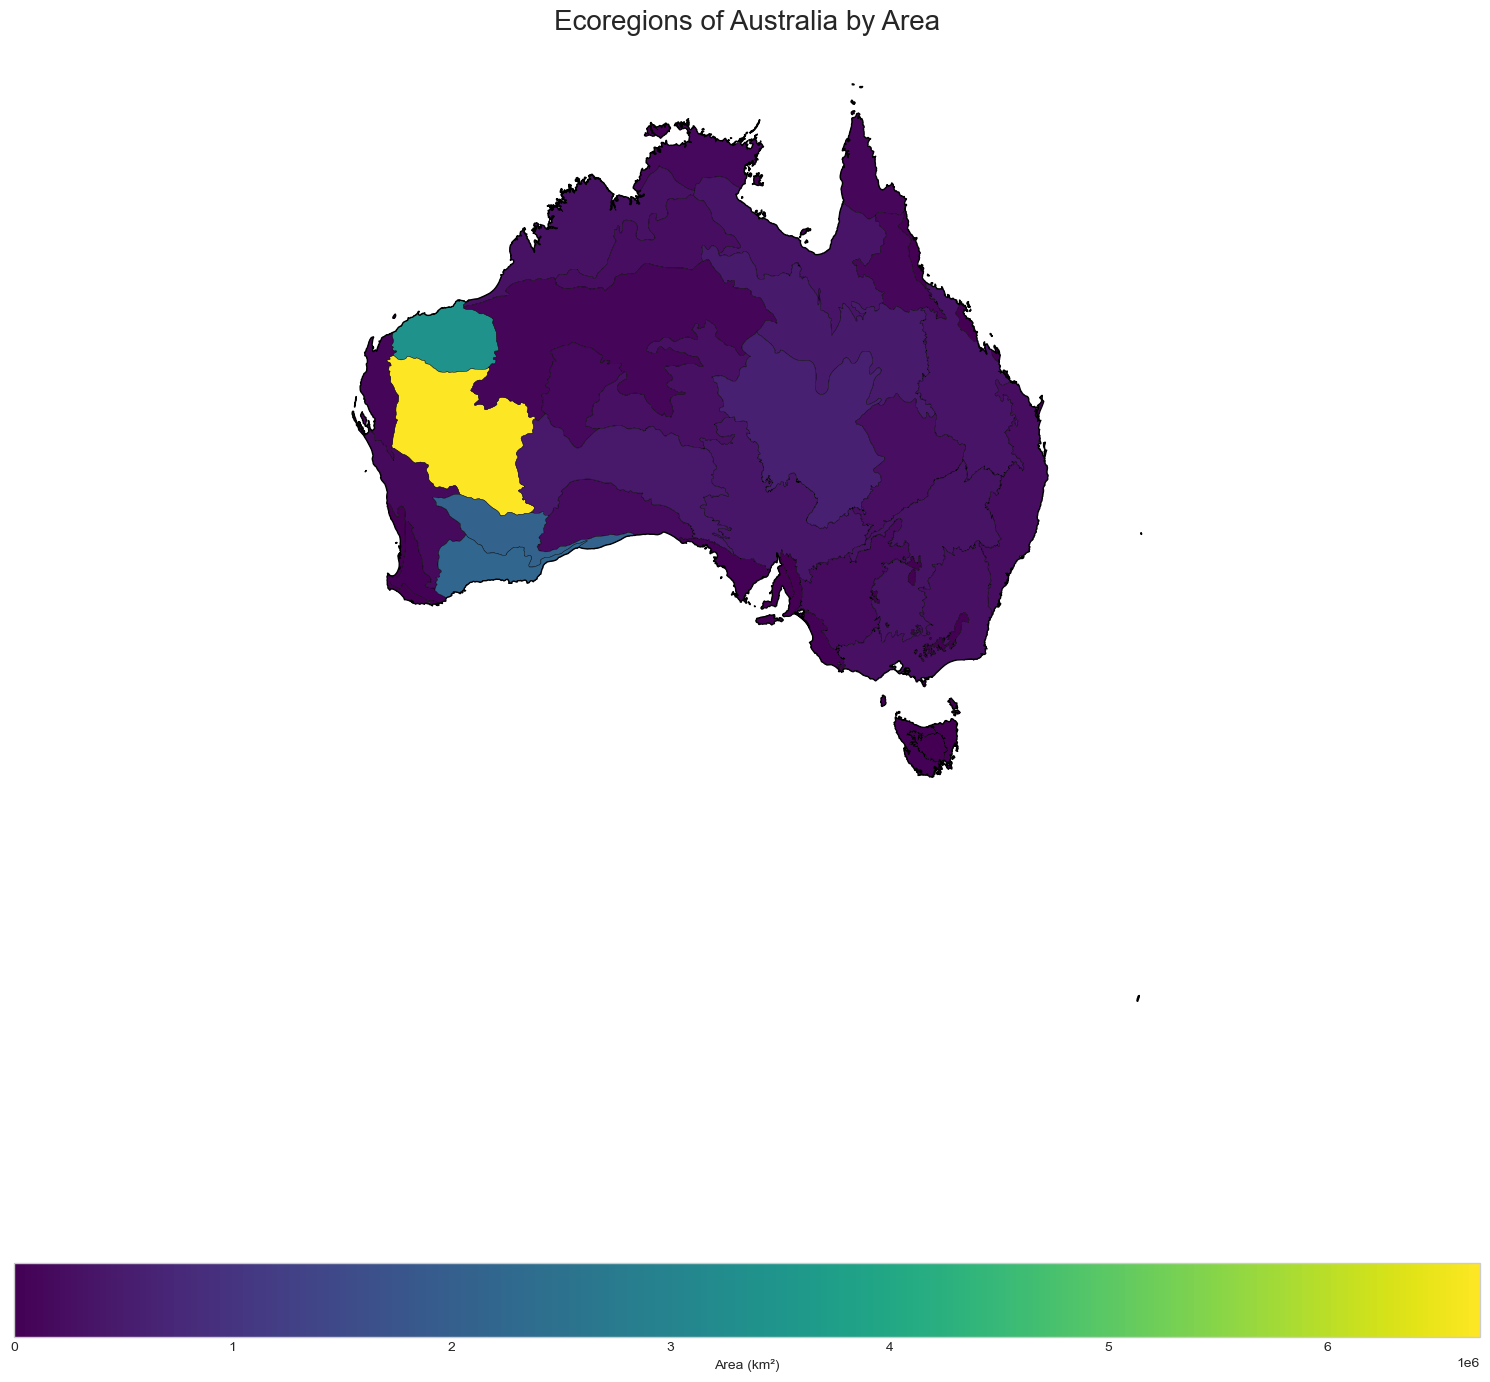

In [4]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot all ecoregions colored by area
brazil_ecoregions.plot(column='area_km2', ax=ax, legend=True,
                       legend_kwds={'label': "Area (km²)", 'orientation': "horizontal"},
                       cmap='viridis', edgecolor='black', linewidth=0.3)

# Plot Australia boundary on top for clarity
australia.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_title("Ecoregions of Australia by Area", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Identify Ecoregions with Copper Mines

In [18]:
# Filter for Copper mines
# Check columns first to be sure 'primary_commodity' or similar exists. Based on prev inspection it was 'primary_commodity'
copper_mines = facilities[facilities['primary_commodity'].str.contains('Copper', case=False, na=False)]

# Ensure CRS match
if copper_mines.crs != australia.crs:
    copper_mines = copper_mines.to_crs(australia.crs)

# Filter for mines within Australia
# Spatial join or clip. Since points are simple, clip/intersection is fast.
brazil_copper_mines = gpd.clip(copper_mines, australia)

print(f"Number of Copper mines in Australia: {len(brazil_copper_mines)}")

# Identify ecoregions containing these mines
# Spatial join between Australia Ecoregions and Australia Copper Mines
mines_with_ecoregions = gpd.sjoin(brazil_copper_mines, brazil_ecoregions, how='inner', predicate='within')

# Get unique Eco IDs or Names that have mines
target_eco_names = mines_with_ecoregions['ECO_NAME'].unique()
target_ecoregions = brazil_ecoregions[brazil_ecoregions['ECO_NAME'].isin(target_eco_names)]

print(f"Number of ecoregions with Copper mines: {len(target_ecoregions)}")

Number of Copper mines in Australia: 16
Number of ecoregions with Copper mines: 64


## 5. Plot 2: Ecoregions containing Copper Mines

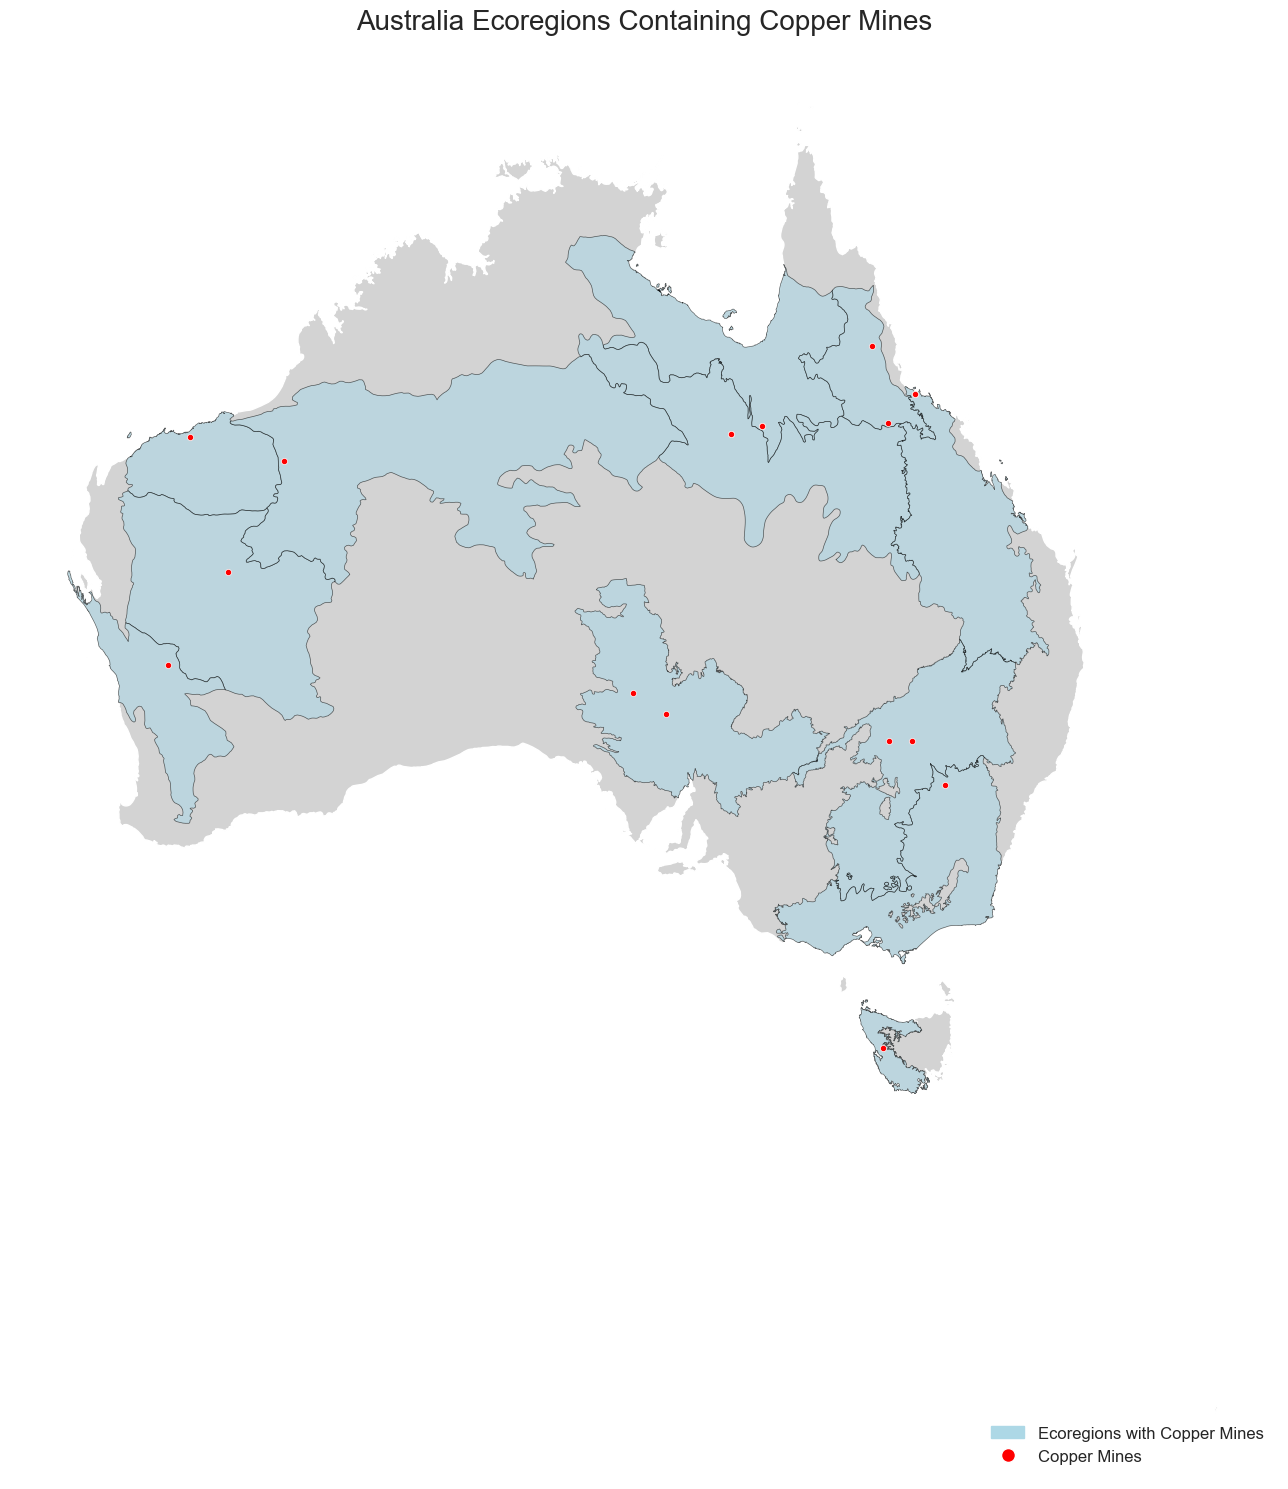

In [19]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot Australia background (faint)
australia.plot(ax=ax, color='lightgrey', edgecolor='white')

# Plot Target Ecoregions
target_ecoregions.plot(ax=ax, color='lightblue', edgecolor='black', alpha=0.6, linewidth=0.5, label='Ecoregions with Copper Mines')

# Plot Mines
brazil_copper_mines.plot(ax=ax, color='red', markersize=20, label='Copper Mines', edgecolor='white', linewidth=0.5)

ax.set_title("Australia Ecoregions Containing Copper Mines", fontsize=20)
ax.set_axis_off()

# Custom legend
import matplotlib.patches as mpatches
eco_patch = mpatches.Patch(color='lightblue', label='Ecoregions with Copper Mines')
mine_marker = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Copper Mines')
plt.legend(handles=[eco_patch, mine_marker], loc='lower right', fontsize=12)

plt.tight_layout()
plt.show()

## 6. Plot 3: Australia Ecoregions by Biome Category

TypeError: Legend.__init__() got an unexpected keyword argument 'label'

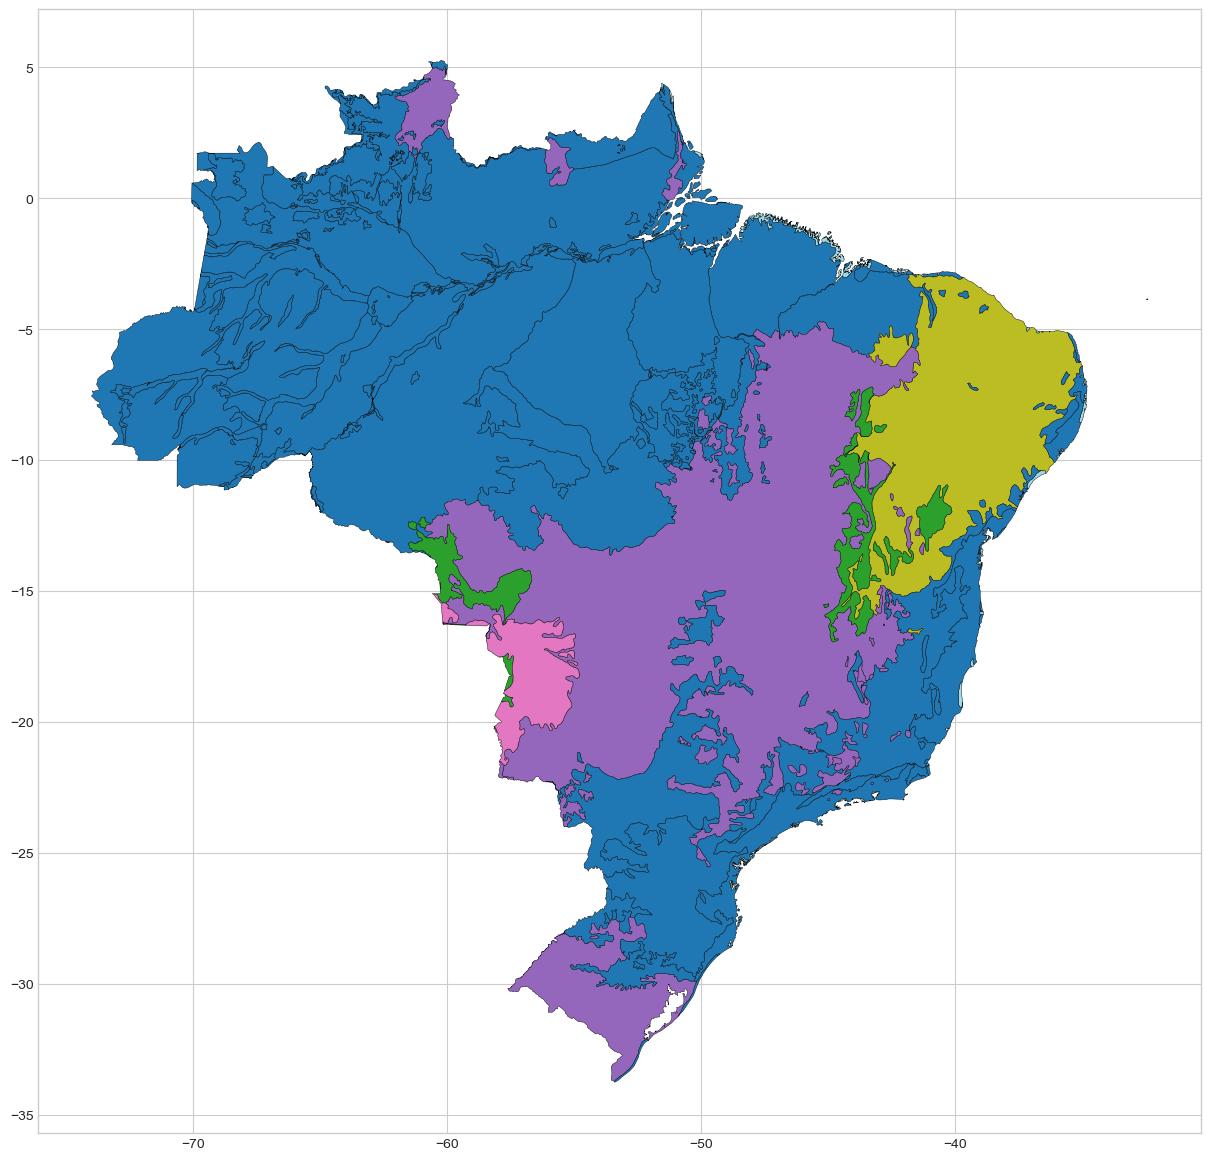

In [ ]:
fig, ax = plt.subplots(figsize=(15, 15))

# Plot all ecoregions colored by biome category
brazil_ecoregions.plot(column='BIOME', ax=ax, legend=True,
                       legend_kwds={'label': "Biome", 'orientation': "vertical", 'bbox_to_anchor': (1.05, 1)},
                       cmap='tab20', edgecolor='black', linewidth=0.3, categorical=True)

# Plot Australia boundary on top for clarity
australia.boundary.plot(ax=ax, color='black', linewidth=1)

ax.set_title("Ecoregions of Australia by Biome Category", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()

In [ ]:
print(brazil_ecoregions.columns.tolist())
print("\nData types:")
print(brazil_ecoregions.dtypes)

['OBJECTID', 'AREA', 'PERIMETER', 'ECO_NAME', 'REALM', 'BIOME', 'ECO_NUM', 'ECO_ID', 'ECO_SYM', 'GBL_STAT', 'G200_REGIO', 'G200_NUM', 'G200_BIOME', 'G200_STAT', 'Shape_Leng', 'Shape_Area', 'area_km2', 'eco_code', 'PER_area', 'PER_area_1', 'PER_area_2', 'featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3', 'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN', 'ADM0_A3', 'GEOU_DIF', 'GEOUNIT', 'GU_A3', 'SU_DIF', 'SUBUNIT', 'SU_A3', 'BRK_DIFF', 'NAME', 'NAME_LONG', 'BRK_A3', 'BRK_NAME', 'BRK_GROUP', 'ABBREV', 'POSTAL', 'FORMAL_EN', 'FORMAL_FR', 'NAME_CIAWF', 'NOTE_ADM0', 'NOTE_BRK', 'NAME_SORT', 'NAME_ALT', 'MAPCOLOR7', 'MAPCOLOR8', 'MAPCOLOR9', 'MAPCOLOR13', 'POP_EST', 'POP_RANK', 'POP_YEAR', 'GDP_MD', 'GDP_YEAR', 'ECONOMY', 'INCOME_GRP', 'FIPS_10', 'ISO_A2', 'ISO_A2_EH', 'ISO_A3', 'ISO_A3_EH', 'ISO_N3', 'ISO_N3_EH', 'UN_A3', 'WB_A2', 'WB_A3', 'WOE_ID', 'WOE_ID_EH', 'WOE_NOTE', 'ADM0_ISO', 'ADM0_DIFF', 'ADM0_TLC', 'ADM0_A3_US', 'ADM0_A3_FR', 'ADM0_A3_RU', 'ADM0_A3_ES', 'ADM0_A3_CN', 'AD